# 01 · Wine Quality — Advanced EDA

## Part 1 — Advanced EDA (Wine Quality)

A thorough cross-sectional EDA: the imbalanced ordinal target, the shapes of all 11 chemical
features, **what actually drives quality**, the **multicollinearity** among the chemistry, and how
**red and white wines differ**.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.clean()
print('wines:', len(df), '| features:', len(data.NUMERIC))

setup ok | numpy 2.1.3 | pandas 2.3.3
wines: 6497 | features: 11


### 1. The target — imbalance & the red/white split

Most wines are rated 5–6; the extremes are scarce. White wines are rated slightly higher on average
than reds — a first hint that the two types behave differently.

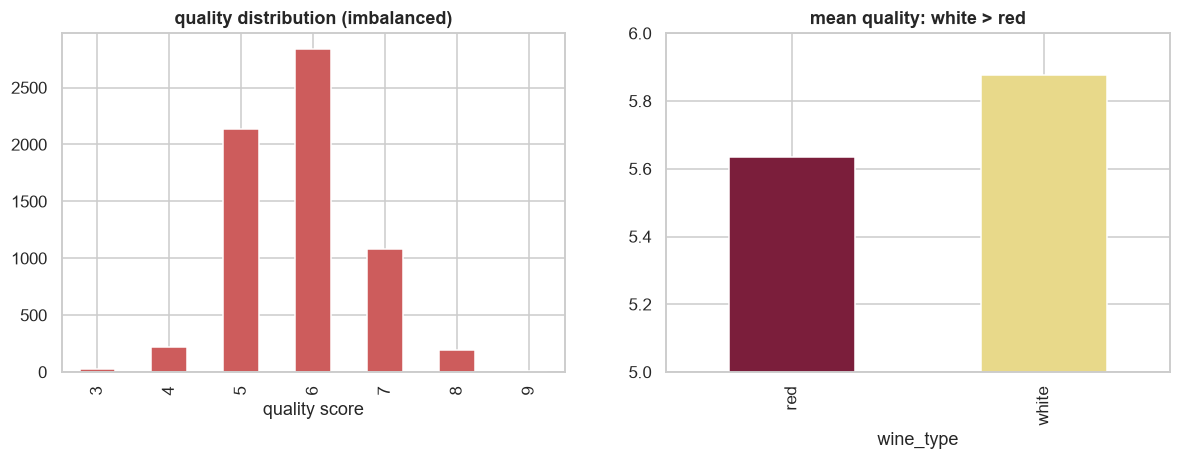

mean quality — red 5.64 vs white 5.88


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.quality.value_counts().sort_index().plot(kind="bar", ax=ax[0], color="indianred"); ax[0].set_title("quality distribution (imbalanced)"); ax[0].set_xlabel("quality score")
df.groupby("wine_type", observed=True).quality.mean().plot(kind="bar", ax=ax[1], color=["#7B1E3B","#E8D98A"]); ax[1].set_title("mean quality: white > red"); ax[1].set_ylim(5, 6)
eda.savefig(fig, "p1_target.png"); plt.show()
print("mean quality — red %.2f vs white %.2f" % (df[df.wine_type=='red'].quality.mean(), df[df.wine_type=='white'].quality.mean()))

### 2. Univariate sweep — every chemical feature

The 11 measurements have very different shapes. Several are **strongly right-skewed** (chlorides,
sulphates, residual sugar) with long tails of outliers — a sign that some features may benefit from a
log transform or robust handling.

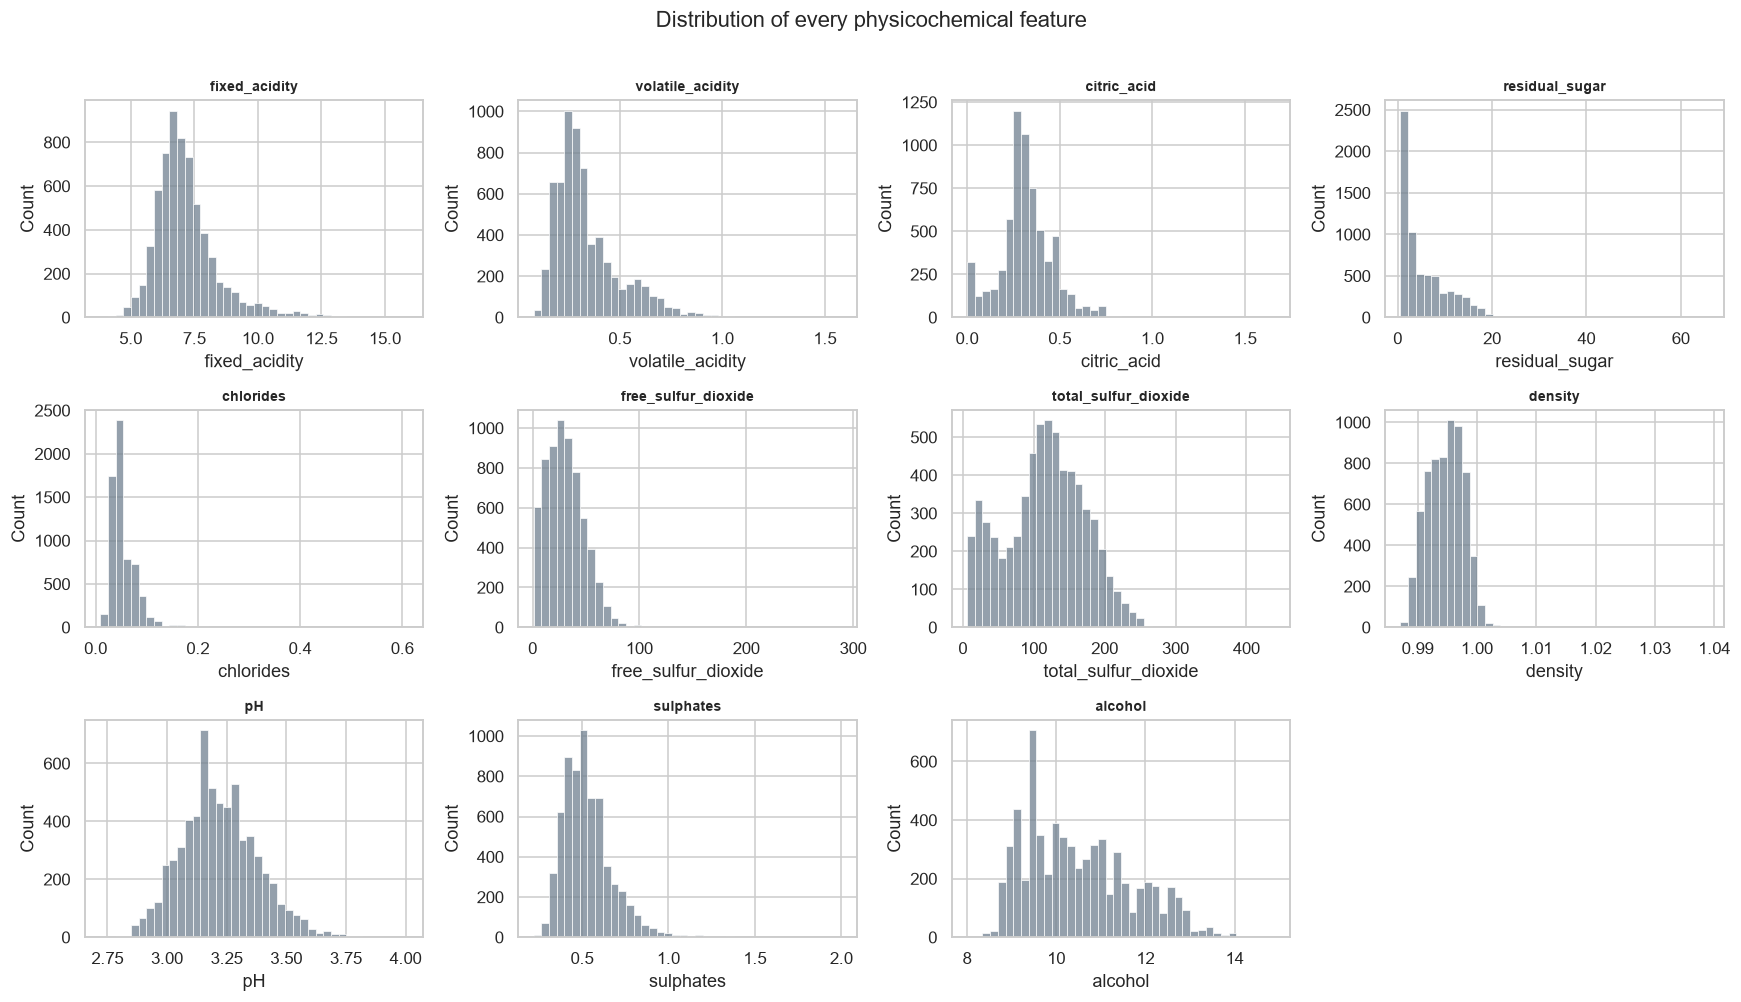

most right-skewed features:
chlorides           5.40
sulphates           1.80
fixed_acidity       1.72
volatile_acidity    1.50


In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), data.NUMERIC):
    sns.histplot(df[c], bins=40, ax=ax, color="slategray"); ax.set_title(c, fontsize=9)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribution of every physicochemical feature", y=1.01); fig.tight_layout()
eda.savefig(fig, "p1_univariate.png"); plt.show()
print("most right-skewed features:"); print(df[data.NUMERIC].skew().round(2).sort_values(ascending=False).head(4).to_string())

### 3. What drives quality?

Correlate each feature with the (ordinal) quality using **Spearman** (rank correlation, right for an
ordinal target). **Alcohol** is by far the strongest positive driver; **volatile acidity** (a vinegar
taint) and **density** pull quality down.

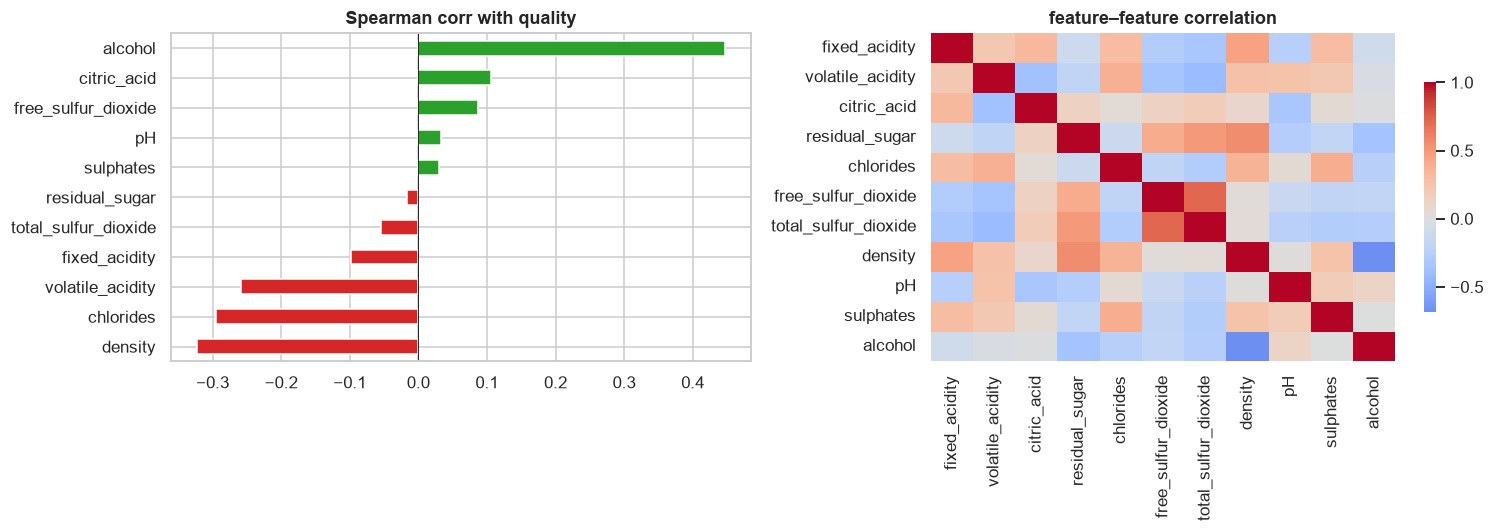

top quality drivers: alcohol +0.45 | volatile_acidity -0.26 | density -0.32


In [4]:
corr_q = df[data.NUMERIC].corrwith(df["quality"], method="spearman").sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
corr_q.plot.barh(ax=ax[0], color=["tab:red" if v<0 else "tab:green" for v in corr_q]); ax[0].set_title("Spearman corr with quality"); ax[0].axvline(0, color="k", lw=.6)
sns.heatmap(df[data.NUMERIC].corr(), cmap="coolwarm", center=0, ax=ax[1], cbar_kws={"shrink":.7}); ax[1].set_title("feature–feature correlation")
fig.tight_layout(); eda.savefig(fig, "p1_drivers.png"); plt.show()
print("top quality drivers: alcohol %+.2f | volatile_acidity %+.2f | density %+.2f"
      % (corr_q["alcohol"], corr_q["volatile_acidity"], corr_q["density"]))

### 4. Multicollinearity — the chemistry is interlinked

Many features are mechanically related: **density** is essentially determined by alcohol and sugar;
**free** SO₂ is part of **total** SO₂. VIF (>5 notable, >10 serious) flags the redundancy — important
because collinear features make linear-model coefficients unstable and muddy "importance".

In [5]:
vif = eda.vif_table(df[data.NUMERIC])
print(vif.round(1).to_string(index=False))
print("\n-> density is the most collinear (it's ~a function of alcohol + sugar + acids); SO2 pair is linked too.")

             feature  VIF
             density 15.9
      residual_sugar  7.2
       fixed_acidity  4.9
             alcohol  4.8
total_sulfur_dioxide  2.9
                  pH  2.5
 free_sulfur_dioxide  2.1
    volatile_acidity  1.9
           chlorides  1.6
         citric_acid  1.6
           sulphates  1.5

-> density is the most collinear (it's ~a function of alcohol + sugar + acids); SO2 pair is linked too.


### 5. Red vs white — two different wines

The `wine_type` flag hides a large chemical gap. White wines carry far more **residual sugar** and
**total SO₂** (preservative), reds far more **volatile acidity** and **chlorides**. They're almost
separable on chemistry alone (which Part 2's PCA will confirm).

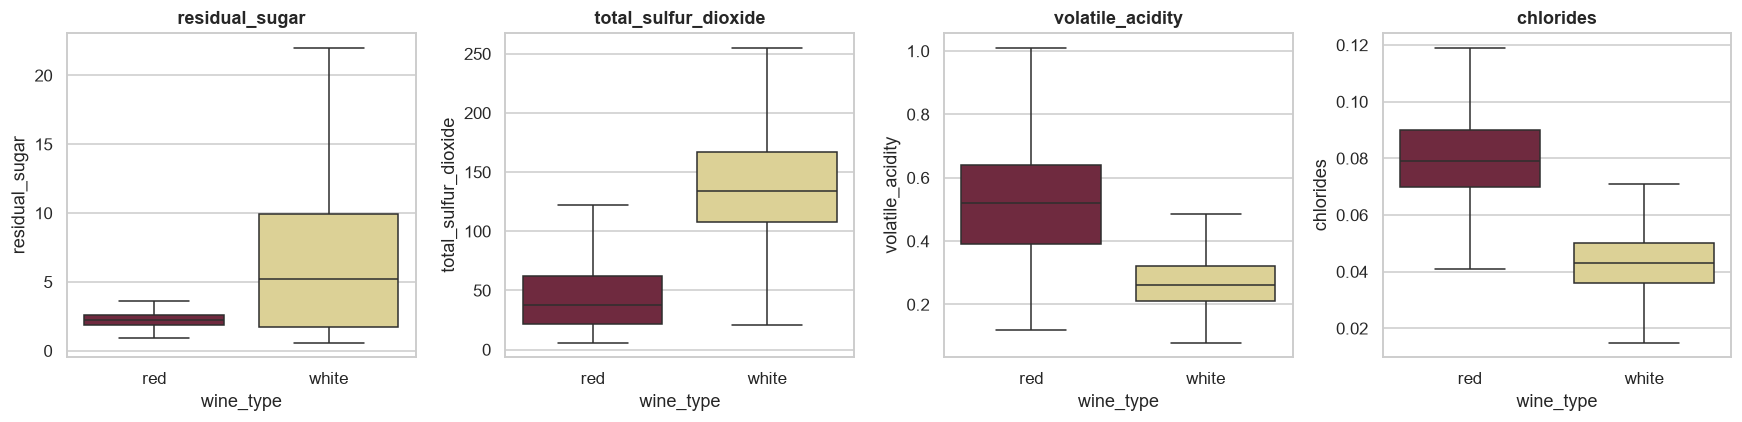

white has 2.5x the sugar and 3.0x the total SO2; red has 1.9x the volatile acidity


In [6]:
feats = ["residual_sugar", "total_sulfur_dioxide", "volatile_acidity", "chlorides"]
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(ax, feats):
    sns.boxplot(x="wine_type", y=c, data=df, ax=a, palette=["#7B1E3B","#E8D98A"], showfliers=False); a.set_title(c)
fig.tight_layout(); eda.savefig(fig, "p1_redwhite.png"); plt.show()
print("white has %.1fx the sugar and %.1fx the total SO2; red has %.1fx the volatile acidity"
      % (df[df.wine_type=='white'].residual_sugar.mean()/df[df.wine_type=='red'].residual_sugar.mean(),
         df[df.wine_type=='white'].total_sulfur_dioxide.mean()/df[df.wine_type=='red'].total_sulfur_dioxide.mean(),
         df[df.wine_type=='red'].volatile_acidity.mean()/df[df.wine_type=='white'].volatile_acidity.mean()))

### 6. The 'good wine' picture

The two strongest drivers, seen directly: average **alcohol rises** steadily with quality, while
**volatile acidity falls** — higher-rated wines are stronger and less acetic.

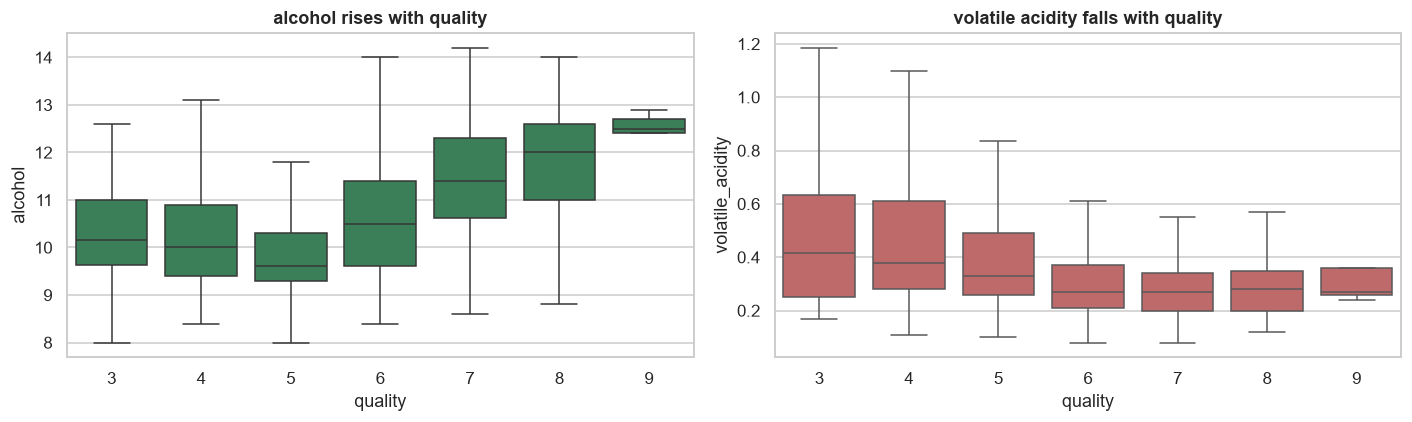

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x="quality", y="alcohol", data=df, ax=ax[0], color="seagreen", showfliers=False); ax[0].set_title("alcohol rises with quality")
sns.boxplot(x="quality", y="volatile_acidity", data=df, ax=ax[1], color="indianred", showfliers=False); ax[1].set_title("volatile acidity falls with quality")
fig.tight_layout(); eda.savefig(fig, "p1_goodwine.png"); plt.show()

### Takeaways

- **Cross-sectional & numeric**: 11 clean physicochemical features, no missing values — but **18%
  duplicate rows** (a leakage risk handled by `dedup()` before modelling).
- The **ordinal target is imbalanced** (mid grades 77%; quality 9 only 5 wines) — accuracy alone will
  be misleading; later we'll need macro-F1 / per-class metrics and imbalance handling.
- **Alcohol is the top quality driver** (Spearman +0.4); volatile acidity and density hurt. Several
  features are **right-skewed** with outliers.
- The chemistry is **collinear** (density ≈ alcohol+sugar; free/total SO₂) — a VIF story for any linear
  model.
- **Red and white are chemically distinct** (sugar, SO₂, volatile acidity) — almost separable.

**Next — Part 2 (Multivariate structure):** PCA of the chemistry (does it separate red/white and
track quality?), and the relationships that a single correlation misses — before we move to
imbalanced ordinal **classification** of quality.